# Exercise 2

We consider the one-dimensional unstead heat diffusion problem with Dirichlet boundary conditions
$$
\begin{align*}
\partial_t u(x,t) = \epsilon\partial_{xx}u(x,t),&& -1<x<1,\,t>0,\\
u(-1,t) = g_L(t), && t>0,\\
u(1,t) = g_R(t), && t>0,\\
u(x,0) = \eta(x), && -1\leq x\leq1.

\end{align*}
$$

For appropriately chosen $g_L$, $g_R$, and $\eta$, it can be shown that a function of the form
$$
u(x,t) = \sum_{i=1}^N\exp{(-\epsilon\alpha_{i}^{2} t)}[a_{i}\cos{(\alpha_{i} x)} + b_i\sin{(\alpha_{i} x)}]
$$

In this problem we will take $N = 3,\,\alpha_{1} = 1,\,\alpha_{2}=4,\,\alpha_{3}=16,\,a_i = 1,\, b_i=0$. 

We also set the diffusion constant $\epsilon = 0.1$

### 1)

We can approximate the spacial derivatives using a central difference equation and the temporal derivatives using a forward stencil. i.e
$$
(u_t)^n_j = \frac{u^{n+1}_{j}- u^{n}_j}{k}
$$
$$
(u_{xx})^n_j = \frac{u_{j+1}^n + u_{j-1}^n - 2u_j^n}{h^2}
$$
Inserting this into the equation yields
$$
\frac{u^{n+1}_{j}- u^{n}_j}{k} = \epsilon\frac{u_{j+1}^n + u_{j-1}^n - 2u_j^n}{h^2}
$$

We can now define the scheme by isolating $u_j^{n+1}$
$$
u^{n+1}_{j} = \epsilon k\frac{u_{j+1}^n + u_{j-1}^n - 2u_j^n}{h^2} + u^{n}_j
$$

### 2)
Looking at the finite difference scheme defined above we can define the iteration matrix as follows
$$
\textbf{u}^{n+1} =\left( 
\frac{\epsilon k}{h^2}
\begin{bmatrix}
-2 & 1 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & \cdots & 0 \\
0 & 0 & 1 & -2 & \cdots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & 1 \\
0 & 0 & 0 & 0 & 1 & -2
\end{bmatrix} + \textbf{I}\right)
\textbf{u}^{n}
$$

From `(2.23)` the eigenvalues this matrix is
$$
\lambda_p = \frac{2 \epsilon k}{h^2}\left(\cos{(p\pi h)-1}\right) + 1
$$
All of these lie on the real axis and span the interval $[\frac{-4\epsilon k}{h^2}+1,\;1]$.
For the scheme to have absolute stability we must require that the eigenvalues are withing the unit circle 
$$
\left|\lambda_p\right|<1
$$
so 
$$
-1<\frac{-4\epsilon k}{h^2}+1<1 \implies 2>\frac{4\epsilon k}{h^2}>0
$$
$$
\frac{h^2}{2\epsilon}>k>0
$$

### 3)
The finite difference approximation applied to a parabolic IBVP should satisfy the `Descrete Maximum Principle` (DMP). 
Given our FD approximation
$$
u^{n+1}_{j} = \epsilon k\frac{u_{j+1}^n + u_{j-1}^n - 2u_j^n}{h^2} + u^{n}_j,
$$
We apply the $\theta$ - method. From slides week 10, we see that 
$$
\mu = \frac{\epsilon k}{h^2}, \quad \theta = 0
$$
For $\mu(1-\theta)\leq \frac{1}{2}$ the solution satisfies the DMP. Plugging in we see that
$$
\frac{\epsilon k}{h^2} \leq \frac{1}{2} \implies k \leq \frac{h^2}{2\epsilon}
$$

This is essentially the same condition as obtained from the stability analysis in part (2), except that the DMP allows equality. Hence, for this scheme, the conditions for stability and the discrete maximum principle coincide.
### 4)
From part **(2)**, we established that the scheme is `stable` provided that
$$
0 \le \frac{\epsilon k}{h^2} \le \frac{1}{2}.
$$
To apply the Lax–Richtmyer theorem, we need to show that the scheme is `consistent`.
Consider the exact solution of the PDE. Using Taylor expansion in time we get
$$
u(x_j, t_{n+1}) = u(x_j,t_n) + k,u_t(x_j,t_n) + \frac{k^2}{2}u_{tt}(x_j,t_n) + O(k^3),
$$
which gives
$$
\frac{u(x_j,t_{n+1}) - u(x_j,t_n)}{k} = u_t(x_j,t_n) + O(k).
$$
Similarly using Taylor expansion in space gives
$$
u(x_j + h, t_n) = u(x_j,t_n) + h u_x + \frac{h^2}{2}u_{xx} + \frac{h^3}{6}u_{xxx} + O(h^4)
$$
$$
u(x_j - h, t_n) = u(x_j,t_n) - h u_x + \frac{h^2}{2}u_{xx} - \frac{h^3}{6}u_{xxx} - O(h^4)
$$
adding them gives
$$
u(x_j + h, t_n) + u(x_j - h, t_n) = 2u(x_j,t_n) + h^2u_{xx} + O(h^4).
$$
Substituting this into the FD scheme we get
$$
u_t = \epsilon u_{xx} + O(k) + O(h^2).
$$

So the local truncation error satisfies 
$$
\tau = O(k + h^2) \rightarrow 0, \;\text{as}\; k,h\rightarrow 0,
$$
thus the scheme is consitent, and by the Lax-Richtmyer theorem it is also convergent
$$
\text{Consitency} + \text{Stability} = \text{Convergence}.
$$


### 5)
We will now apply our FTCS scheme to visually demonstrate the convergence. This can both be demonstrated for the spatial and temporal convergence, assuming k are chosen to satisfy the stability condition. 

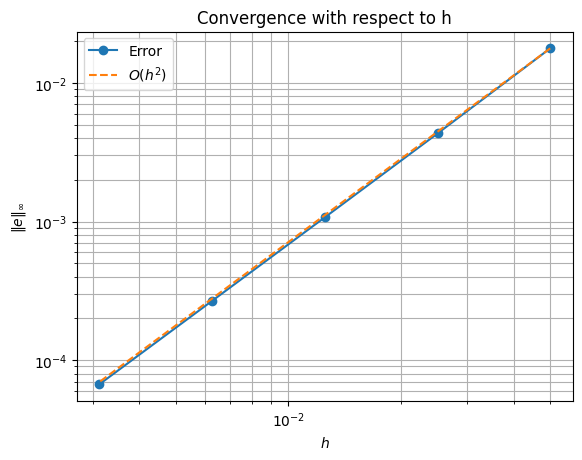

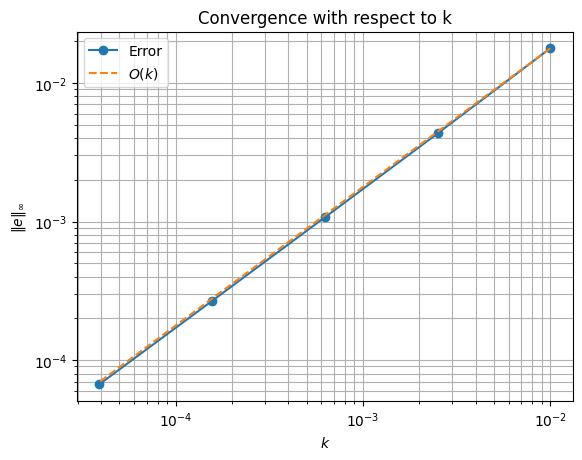

In [3]:
import numpy as np
import matplotlib.pyplot as plt

epsilon = 0.1
T = 0.1

def exact_solution(x, t):
    return (
        np.exp(-epsilon * t) * np.cos(x)
        + np.exp(-16 * epsilon * t) * np.cos(4*x)
        + np.exp(-256 * epsilon * t) * np.cos(16*x)
    )

def solve_ftcs(N):
    h = 2 / N

    # Choosing k according to stability condition
    k = 0.4 * h**2 / epsilon
    M = int(np.ceil(T / k))
    k = T / M

    x = np.linspace(-1, 1, N+1)
    u = exact_solution(x, 0)

    mu = epsilon * k / h**2

    for n in range(M):
        t_next = (n+1) * k
        u_new = u.copy()

        u_new[1:-1] = (
            u[1:-1]
            + mu * (u[2:] - 2*u[1:-1] + u[:-2])
        )

        # Dirichlet boundary values
        u_new[0] = exact_solution(-1, t_next)
        u_new[-1] = exact_solution(1, t_next)

        u = u_new

    error = np.max(np.abs(u - exact_solution(x, T)))
    return h, k, error

Ns = [40, 80, 160, 320, 640]

hs = []
ks = []
errors = []

for N in Ns:
    h, k, err = solve_ftcs(N)
    hs.append(h)
    ks.append(k)
    errors.append(err)

hs = np.array(hs)
ks = np.array(ks)
errors = np.array(errors)

# Rates with respect to h
rates_h = np.log(errors[:-1] / errors[1:]) / np.log(hs[:-1] / hs[1:])

# Rates with respect to k
rates_k = np.log(errors[:-1] / errors[1:]) / np.log(ks[:-1] / ks[1:])

# Plot error vs h
plt.figure()
plt.loglog(hs, errors, "o-", label="Error")
plt.loglog(hs, errors[0]*(hs/hs[0])**2, "--", label=r"$O(h^2)$")
plt.xlabel(r"$h$")
plt.ylabel(r"$\|e\|_\infty$")
plt.title("Convergence with respect to h")
plt.legend()
plt.grid(True, which="both")
plt.show()

# Plot error vs k
plt.figure()
plt.loglog(ks, errors, "o-", label="Error")
plt.loglog(ks, errors[0]*(ks/ks[0]), "--", label=r"$O(k)$")
plt.xlabel(r"$k$")
plt.ylabel(r"$\|e\|_\infty$")
plt.title("Convergence with respect to k")
plt.legend()
plt.grid(True, which="both")
plt.show()

Convergence looks like expected!